In [46]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats

In [47]:
# Set the random seed for reproducibility
np.random.seed(42)

In [48]:
# Create sample dataset with outliers
df = pd.DataFrame({
    'height': np.concatenate([
        np.random.normal(175, 7, 95),  # Normal heights in cm
        np.array([150, 155, 200, 205, 210])  # Outliers
    ]),
    'weight': np.concatenate([
        np.random.normal(70, 10, 95),  # Normal weights in kg
        np.array([40, 45, 120, 125, 130])  # Outliers
    ]),
    'salary': np.concatenate([
        np.random.lognormal(10.5, 0.4, 95),  # Normal salaries
        np.array([500000, 520000, 550000, 600000, 1000000])  # Outliers
    ])
})

In [49]:
# Display dataset head and basic statistics
df.head()

,height,weight,salary
0,178.476999,55.364851,30375.572226
1,174.032150,72.961203,51152.135370
2,179.533820,72.610553,39562.520524
3,185.661209,70.051135,22064.041668
4,173.360926,67.654129,38920.343822


In [50]:
# Quick data summary
df.describe()


,height,weight,salary
count,100.000000,100.000000,100.000000
mean,174.802581,71.397280,70575.816571
std,8.824677,13.932214,138019.017873
min,150.000000,40.000000,9931.760814
25%,170.712081,61.943395,27742.715939
50%,174.111306,70.841072,38441.915870
75%,178.918874,76.333889,51091.331090
max,210.000000,130.000000,1000000.000000


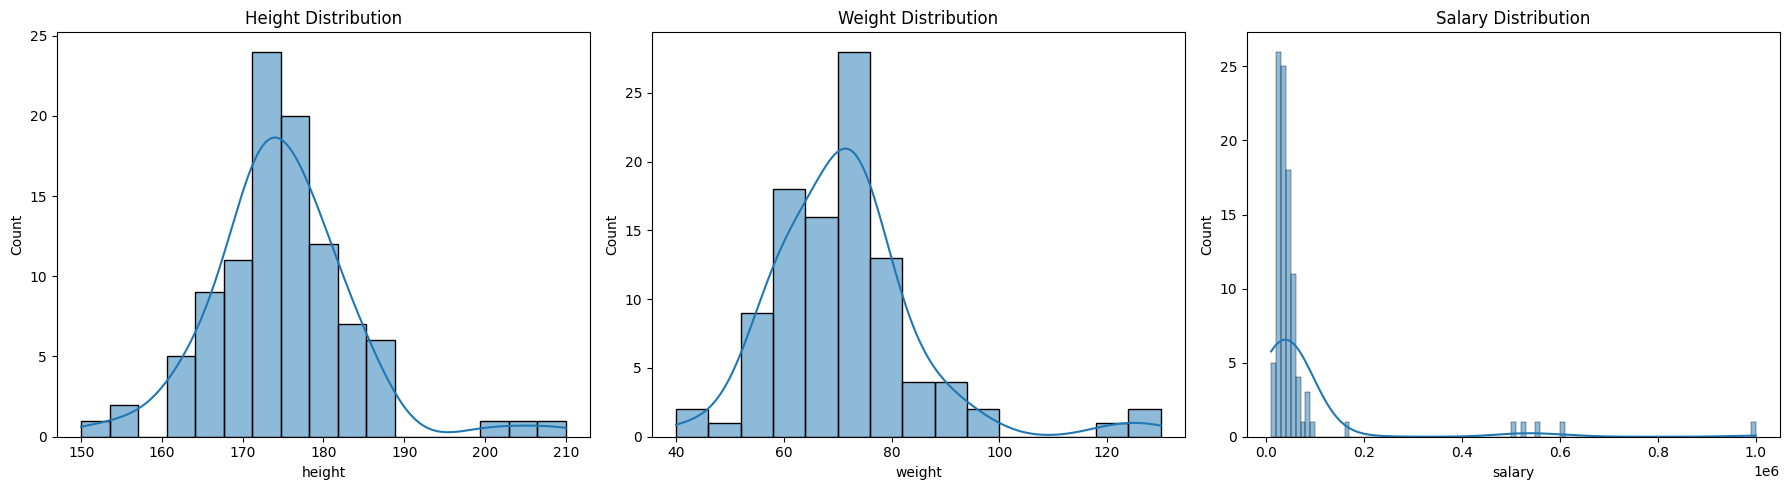

In [51]:
# Visualize distributions to identify potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.histplot(df['height'], kde=True)
plt.title('Height Distribution')

plt.subplot(1, 3, 2)
sns.histplot(df['weight'], kde=True)
plt.title('Weight Distribution')

plt.subplot(1, 3, 3)
sns.histplot(df['salary'], kde=True)
plt.title('Salary Distribution')

plt.tight_layout()
plt.show()

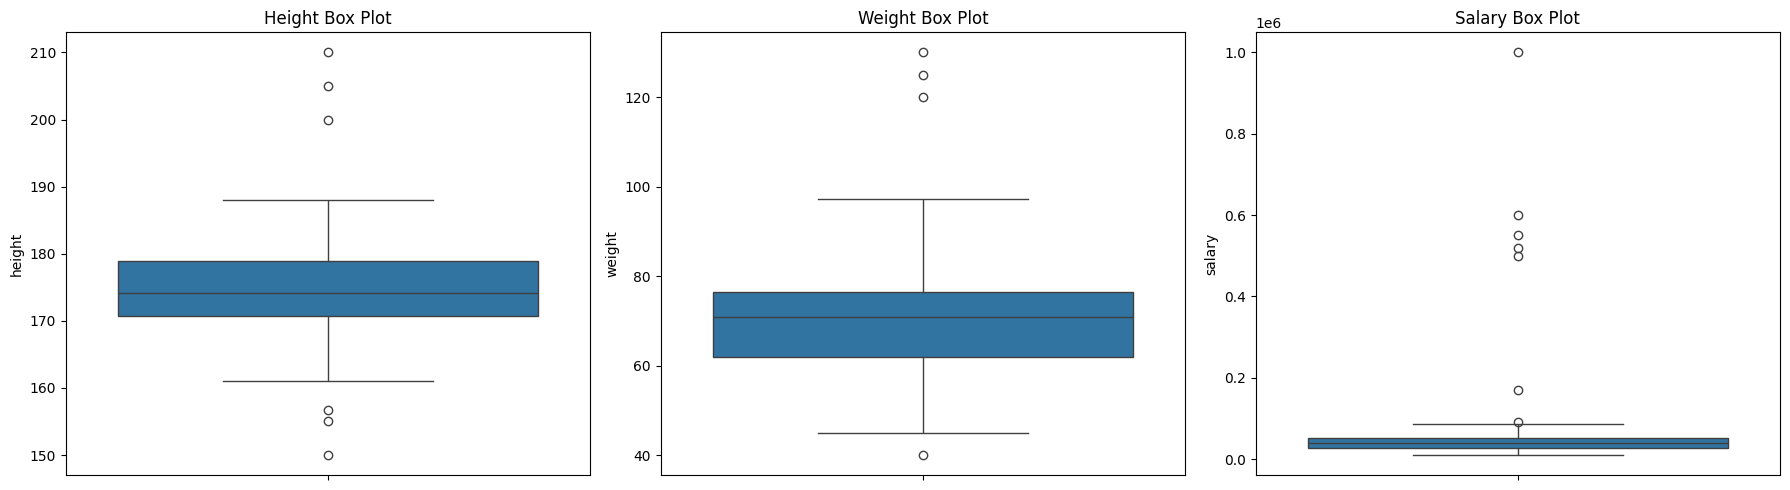

In [52]:
# Box plots to visualize potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')

plt.subplot(1, 3, 2)
sns.boxplot(y=df['weight'])
plt.title('Weight Box Plot')

plt.subplot(1, 3, 3)
sns.boxplot(y=df['salary'])
plt.title('Salary Box Plot')

plt.tight_layout()
plt.show()

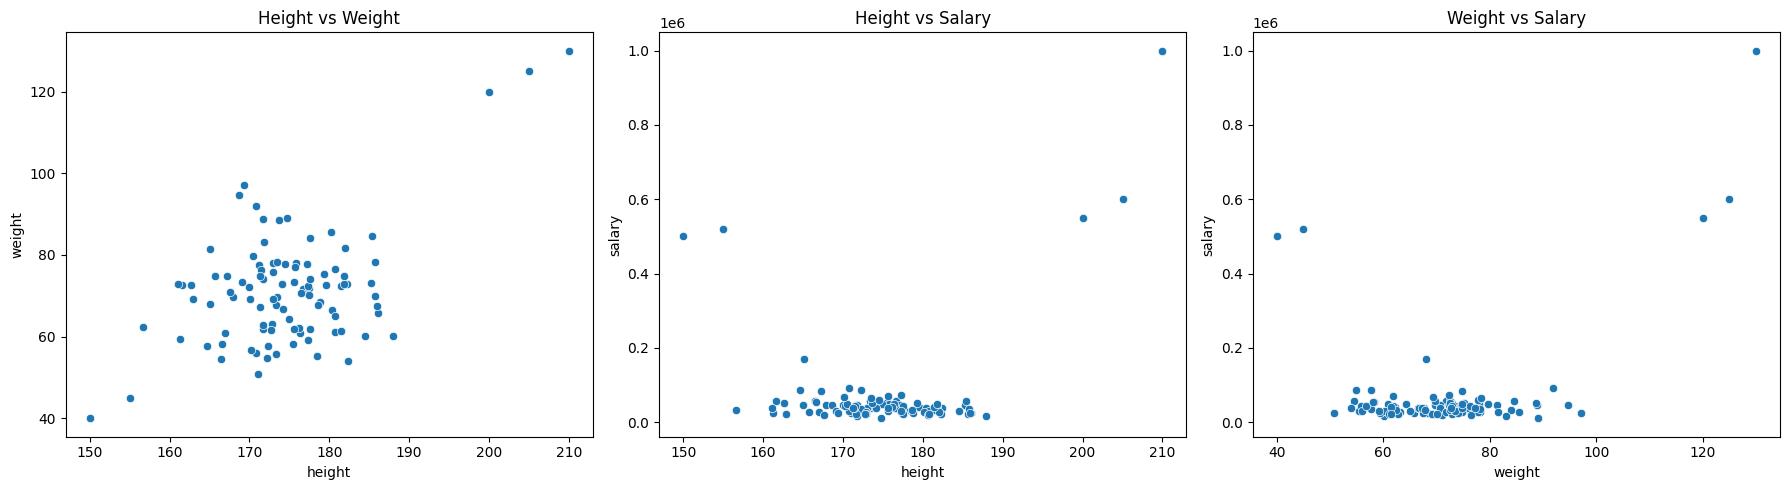

In [53]:
# Scatter plots to identify patterns and potential outliers
plt.figure(figsize=(18, 5))

plt.subplot(1, 3, 1)
sns.scatterplot(x='height', y='weight', data=df)
plt.title('Height vs Weight')

plt.subplot(1, 3, 2)
sns.scatterplot(x='height', y='salary', data=df)
plt.title('Height vs Salary')

plt.subplot(1, 3, 3)
sns.scatterplot(x='weight', y='salary', data=df)
plt.title('Weight vs Salary')

plt.tight_layout()
plt.show()

In [54]:
# Define function for Z-score outlier detection
def detect_outliers_zscore(data, threshold=3):
    """
    Detect outliers using Z-score method
    Returns indices of outliers
    """
    z_scores = np.abs(stats.zscore(data))
    return np.where(z_scores > threshold)[0]


In [55]:
# Apply Z-score outlier detection
height_outliers_z = detect_outliers_zscore(df['height'])
weight_outliers_z = detect_outliers_zscore(df['weight'])
salary_outliers_z = detect_outliers_zscore(df['salary'])

print(f"Height outliers (Z-score): {len(height_outliers_z)} found at indices {height_outliers_z}")
print(f"Weight outliers (Z-score): {len(weight_outliers_z)} found at indices {weight_outliers_z}")
print(f"Salary outliers (Z-score): {len(salary_outliers_z)} found at indices {salary_outliers_z}")


Height outliers (Z-score): 2 found at indices [98 99]
Weight outliers (Z-score): 3 found at indices [97 98 99]
Salary outliers (Z-score): 5 found at indices [95 96 97 98 99]


In [56]:
# Define function for IQR outlier detection
def detect_outliers_iqr(data, factor=1.5):
    """
    Detect outliers using IQR method
    Returns indices of outliers
    """
    q1, q3 = np.percentile(data, [25, 75])
    iqr = q3 - q1
    lower_bound = q1 - (factor * iqr)
    upper_bound = q3 + (factor * iqr)
    return np.where((data < lower_bound) | (data > upper_bound))[0]


In [57]:
# Apply IQR outlier detection
height_outliers_iqr = detect_outliers_iqr(df['height'])
weight_outliers_iqr = detect_outliers_iqr(df['weight'])
salary_outliers_iqr = detect_outliers_iqr(df['salary'])

print(f"Height outliers (IQR): {len(height_outliers_iqr)} found at indices {height_outliers_iqr}")
print(f"Weight outliers (IQR): {len(weight_outliers_iqr)} found at indices {weight_outliers_iqr}")
print(f"Salary outliers (IQR): {len(salary_outliers_iqr)} found at indices {salary_outliers_iqr}")


Height outliers (IQR): 6 found at indices [74 95 96 97 98 99]
Weight outliers (IQR): 4 found at indices [95 97 98 99]
Salary outliers (IQR): 7 found at indices [19 30 95 96 97 98 99]


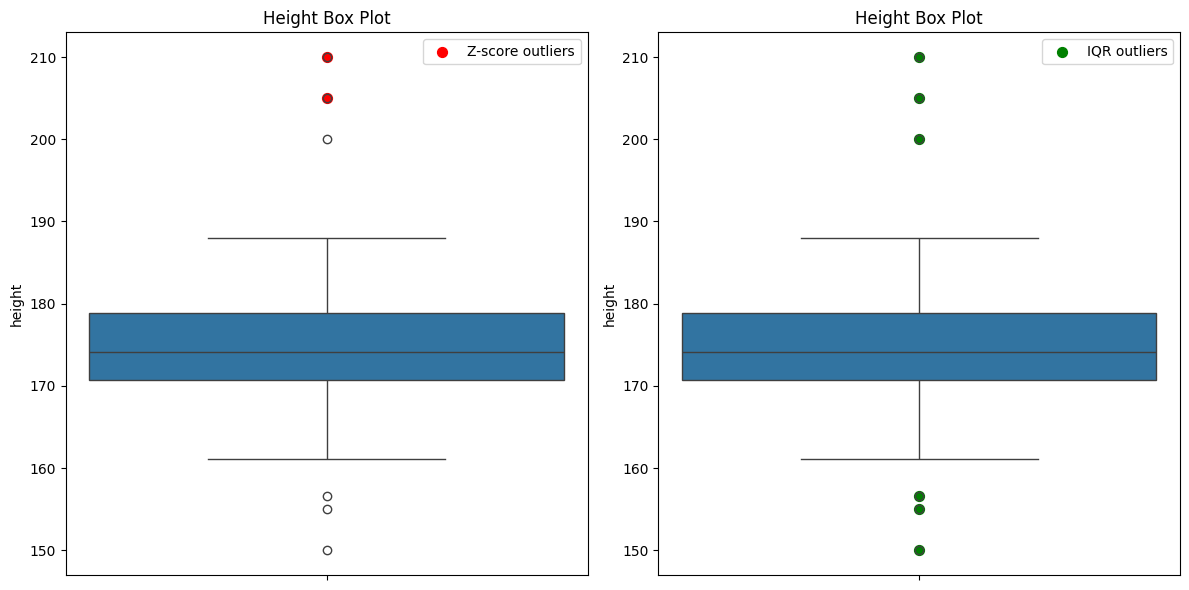

In [58]:
# Visualize the detected outliers for height using box plot with highlighted outliers
plt.figure(figsize=(12, 6))

plt.subplot(1, 2, 1)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_z), df['height'].iloc[height_outliers_z],
            color='red', s=50, label='Z-score outliers')
plt.legend()

plt.subplot(1, 2, 2)
sns.boxplot(y=df['height'])
plt.title('Height Box Plot')
plt.scatter(np.zeros_like(height_outliers_iqr), df['height'].iloc[height_outliers_iqr],
            color='green', s=50, label='IQR outliers')
plt.legend()

plt.tight_layout()
plt.show()


In [59]:
# Examining the impact of outliers on statistical measures
print("With outliers:")
print(f"Height mean: {df['height'].mean():.2f}, std: {df['height'].std():.2f}")
print(f"Weight mean: {df['weight'].mean():.2f}, std: {df['weight'].std():.2f}")
print(f"Salary mean: {df['salary'].mean():.2f}, std: {df['salary'].std():.2f}")


With outliers:
Height mean: 174.80, std: 8.82
Weight mean: 71.40, std: 13.93
Salary mean: 70575.82, std: 138019.02


In [60]:
# Create copies without outliers (using IQR method)
df_no_outliers = df.copy()
all_outliers = list(set(height_outliers_iqr) | set(weight_outliers_iqr) | set(salary_outliers_iqr))
df_no_outliers = df_no_outliers.drop(all_outliers).reset_index(drop=True)

print("\nWithout outliers:")
print(f"Height mean: {df_no_outliers['height'].mean():.2f}, std: {df_no_outliers['height'].std():.2f}")
print(f"Weight mean: {df_no_outliers['weight'].mean():.2f}, std: {df_no_outliers['weight'].std():.2f}")
print(f"Salary mean: {df_no_outliers['salary'].mean():.2f}, std: {df_no_outliers['salary'].std():.2f}")



Without outliers:
Height mean: 174.65, std: 6.18
Weight mean: 70.19, std: 9.50
Salary mean: 39059.91, std: 15713.95


In [61]:
# Handling outliers using different approaches
# 1. Removal (already done above)
# 2. Capping (Winsorization)
def winsorize(data, limits=(0.05, 0.05)):
    """Apply winsorization to limit extreme values"""
    lower_limit = np.percentile(data, limits[0] * 100)
    upper_limit = np.percentile(data, 100 - limits[1] * 100)
    return np.clip(data, lower_limit, upper_limit)

df_winsorized = df.copy()
df_winsorized['height'] = winsorize(df['height'])
df_winsorized['weight'] = winsorize(df['weight'])
df_winsorized['salary'] = winsorize(df['salary'])


In [62]:
# 3. Log transformation (especially useful for skewed data like salary)
df_log = df.copy()
df_log['salary'] = np.log(df['salary'])


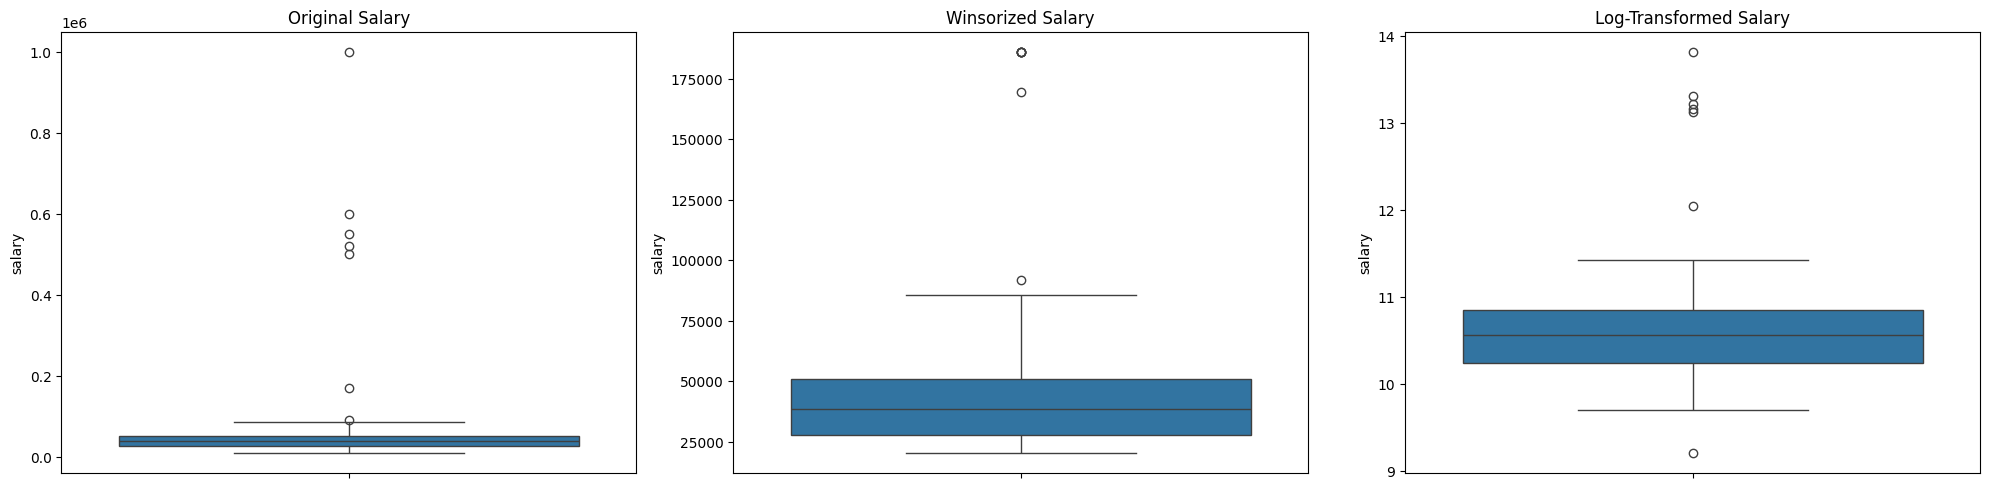

In [63]:
# Compare the distributions before and after transformation
plt.figure(figsize=(20, 5))

# Original distributions
plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

# After winsorization
plt.subplot(1, 3, 2)
sns.boxplot(y=df_winsorized['salary'])
plt.title('Winsorized Salary')

# After log transformation
plt.subplot(1, 3, 3)
sns.boxplot(y=df_log['salary'])
plt.title('Log-Transformed Salary')

plt.tight_layout()
plt.show()

In [64]:
# Feature associations and correlation analysis
# Calculate correlation matrix
corr_matrix = df.corr()


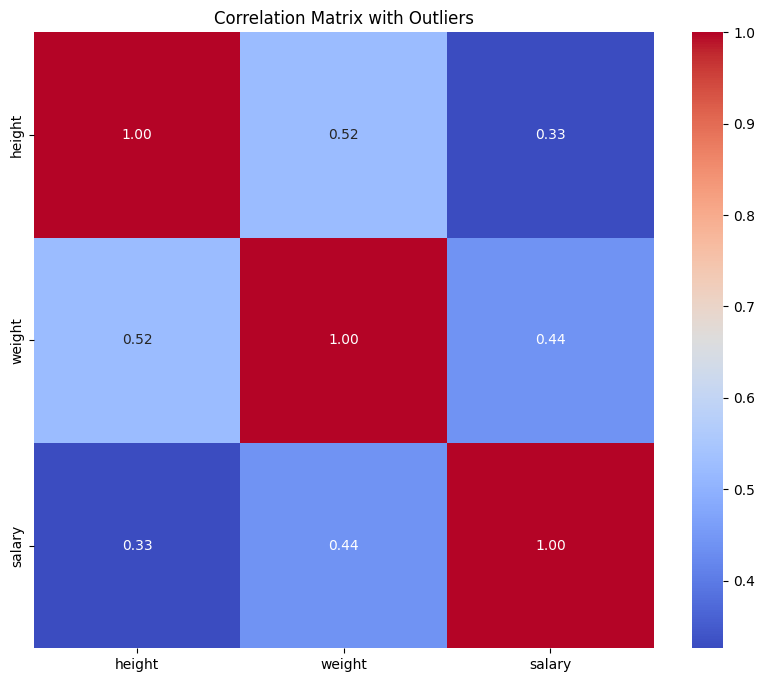

In [65]:
# Visualize the correlation matrix
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix with Outliers')
plt.show()


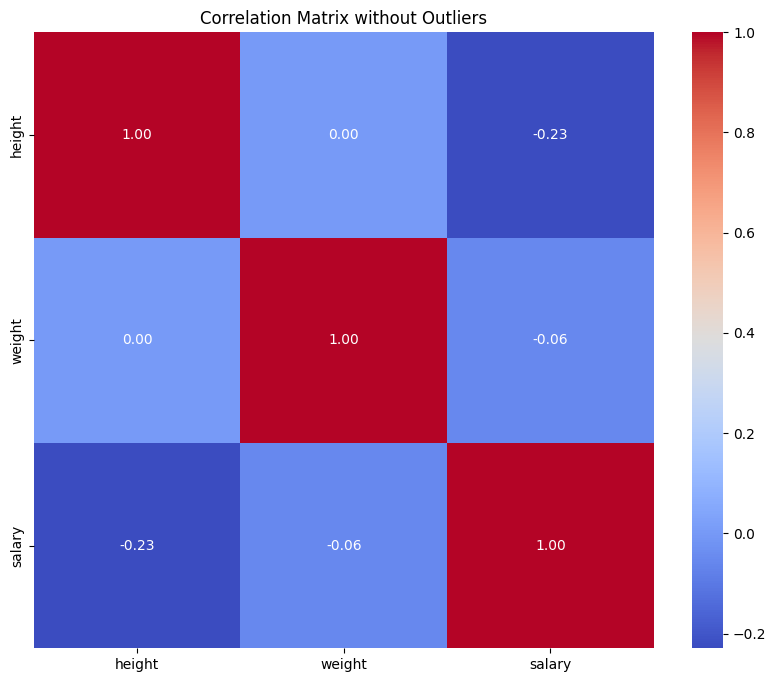

In [66]:
# Compare with correlation after removing outliers
corr_matrix_no_outliers = df_no_outliers.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix_no_outliers, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Matrix without Outliers')
plt.show()


In [67]:
# Create function to profile features and detect potential issues
def profile_feature(data, feature_name):
    """Create a basic profile of a numeric feature"""
    feature = data[feature_name]

    # Basic statistics
    stats_dict = {
        'Count': len(feature),
        'Mean': feature.mean(),
        'Median': feature.median(),
        'Std Dev': feature.std(),
        'Min': feature.min(),
        'Max': feature.max(),
        'Range': feature.max() - feature.min(),
        'IQR': np.percentile(feature, 75) - np.percentile(feature, 25),
        'Skewness': stats.skew(feature),
        'Kurtosis': stats.kurtosis(feature),
        'Missing Values': feature.isna().sum(),
        'Missing %': feature.isna().mean() * 100
    }

    # Z-score outliers
    z_outliers = detect_outliers_zscore(feature)
    stats_dict['Z-score Outliers'] = len(z_outliers)
    stats_dict['Z-score Outlier %'] = len(z_outliers) / len(feature) * 100

    # IQR outliers
    iqr_outliers = detect_outliers_iqr(feature)
    stats_dict['IQR Outliers'] = len(iqr_outliers)
    stats_dict['IQR Outlier %'] = len(iqr_outliers) / len(feature) * 100

    return pd.Series(stats_dict, name=feature_name)


In [68]:
# Apply feature profiling to the dataset
profile_results = pd.DataFrame([
    profile_feature(df, 'height'),
    profile_feature(df, 'weight'),
    profile_feature(df, 'salary')
])

# Display the feature profiles
profile_results


,Count,Mean,Median,Std Dev,Min,Max,Range,IQR,Skewness,Kurtosis,Missing Values,Missing %,Z-score Outliers,Z-score Outlier %,IQR Outliers,IQR Outlier %
height,100.0,174.802581,174.111306,8.824677,150.000000,210.0,60.000000,8.206793,0.802248,3.330725,0.0,0.0,2.0,2.0,6.0,6.0
weight,100.0,71.397280,70.841072,13.932214,40.000000,130.0,90.000000,14.390494,1.587588,4.962706,0.0,0.0,3.0,3.0,4.0,4.0
salary,100.0,70575.816571,38441.915870,138019.017873,9931.760814,1000000.0,990068.239186,23348.615150,4.740303,23.787349,0.0,0.0,5.0,5.0,7.0,7.0


In [69]:
# Fixed function for multivariate outlier detection
def detect_multivariate_outliers(data, method='mahalanobis', threshold=0.99):
    """
    Detect multivariate outliers using Mahalanobis distance
    Returns indices of outliers
    """
    if method == 'mahalanobis':
        # Calculate Mahalanobis distance
        x = data.values
        covariance_matrix = np.cov(x, rowvar=False)
        inv_covariance_matrix = np.linalg.inv(covariance_matrix)
        mean_vector = np.mean(x, axis=0)

        # Implement mahalanobis distance manually
        mahalanobis_dist = []
        for i in range(x.shape[0]):
            x_i = x[i, :]
            # Calculate mahalanobis distance: (x-μ)ᵀΣ⁻¹(x-μ)
            diff = x_i - mean_vector
            mahal = np.sqrt(diff.dot(inv_covariance_matrix).dot(diff.T))
            mahalanobis_dist.append(mahal)

        # Convert to array
        mahalanobis_dist = np.array(mahalanobis_dist)

        # Find threshold using chi-squared distribution
        threshold_value = stats.chi2.ppf(threshold, df=x.shape[1])

        # Return indices of outliers
        return np.where(mahalanobis_dist > threshold_value)[0]
    else:
        raise ValueError("Only 'mahalanobis' method is currently supported")


In [70]:
# Apply multivariate outlier detection
multivariate_outliers = detect_multivariate_outliers(df, threshold=0.95)
print(f"Multivariate outliers: {len(multivariate_outliers)} found at indices {multivariate_outliers}")


Multivariate outliers: 0 found at indices []


<Figure size 1200x1000 with 0 Axes>

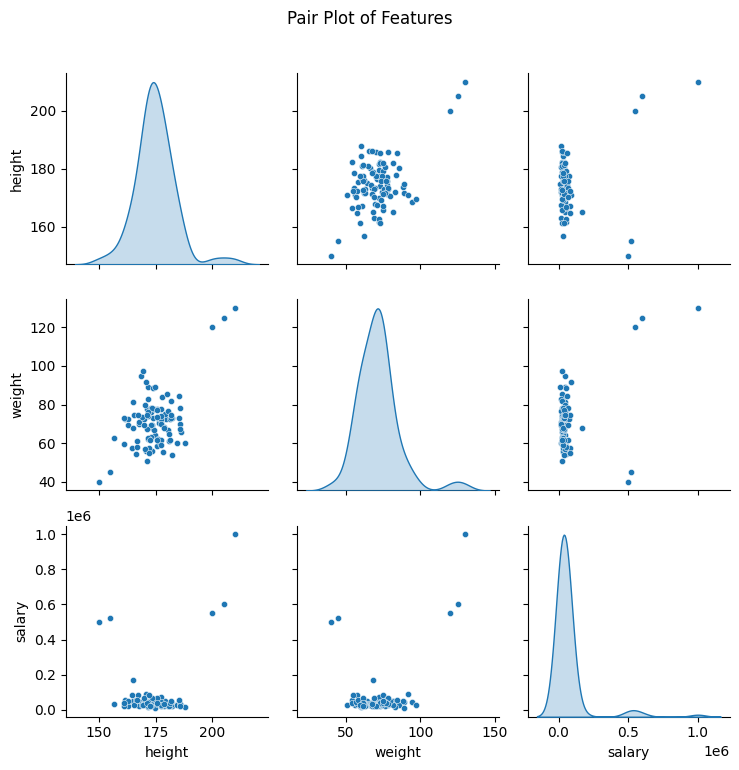

In [71]:
# Visualize the multivariate outliers in a pair plot
plt.figure(figsize=(12, 10))
sns.pairplot(df, diag_kind='kde', plot_kws={"s": 20})
plt.suptitle('Pair Plot of Features', y=1.02)
plt.tight_layout()
plt.show()

C:\Users\hp\AppData\Local\Temp\ipykernel_3232\3117540217.py:7: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


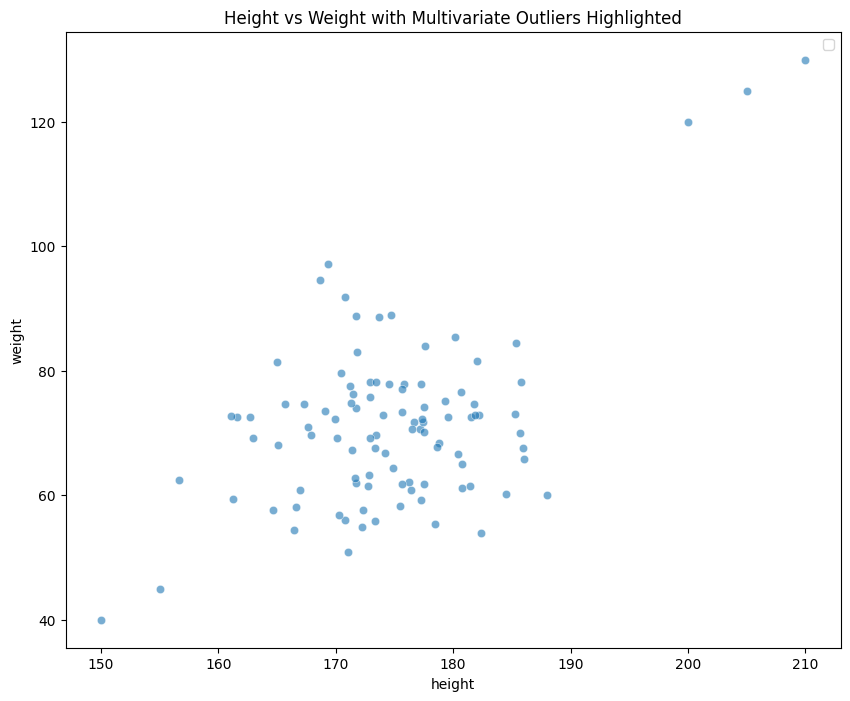

In [72]:
# Highlight the multivariate outliers in a scatter plot
plt.figure(figsize=(10, 8))
sns.scatterplot(x='height', y='weight', data=df, alpha=0.6)
sns.scatterplot(x='height', y='weight', data=df.iloc[multivariate_outliers],
                color='red', s=100, label='Multivariate Outliers')
plt.title('Height vs Weight with Multivariate Outliers Highlighted')
plt.legend()
plt.show()


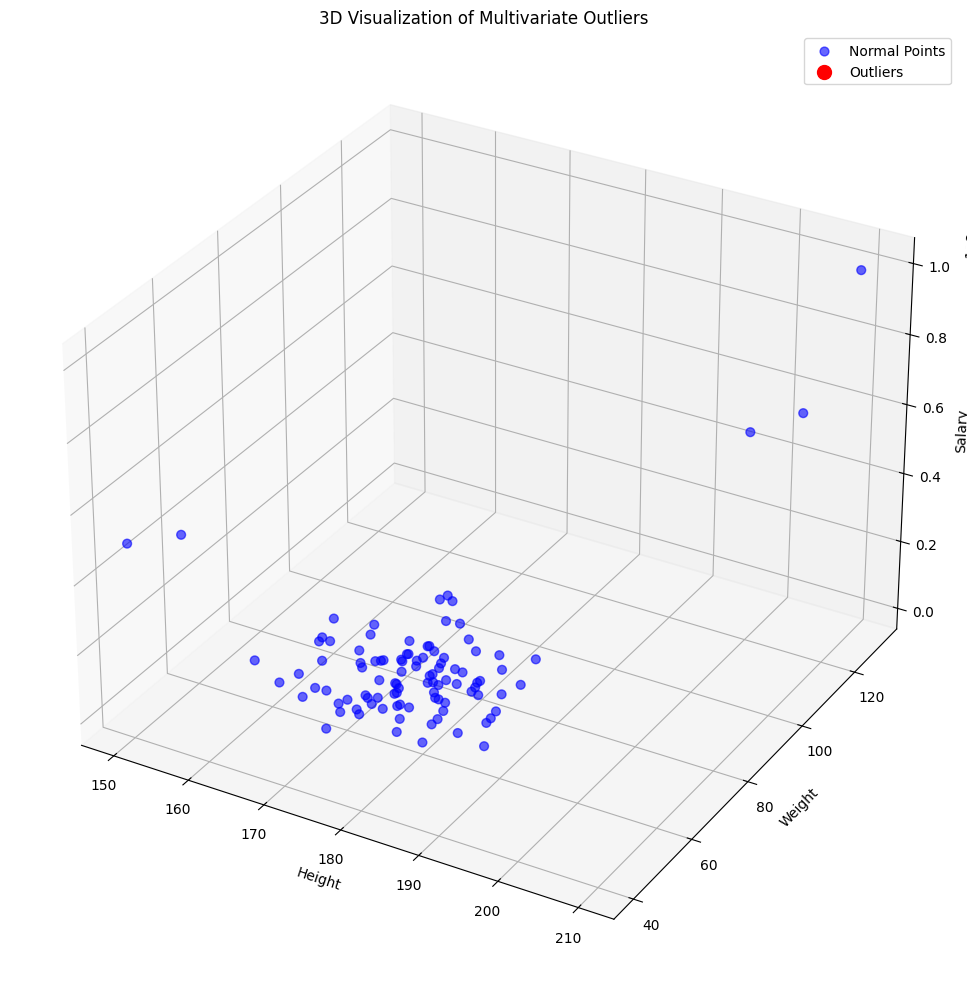

In [76]:
# 3D visualization of outliers
from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 10))
ax = fig.add_subplot(111, projection='3d')

# Regular points
ax.scatter(df['height'], df['weight'], df['salary'], c='blue', s=40, alpha=0.6, label='Normal Points')
# Outliers
ax.scatter(df.iloc[multivariate_outliers]['height'], df.iloc[multivariate_outliers]['weight'],
           df.iloc[multivariate_outliers]['salary'], c='red', s=100, label='Outliers')

ax.set_xlabel('Height')
ax.set_ylabel('Weight')
ax.set_zlabel('Salary')
ax.set_title('3D Visualization of Multivariate Outliers')
plt.legend()
plt.tight_layout()
plt.show()


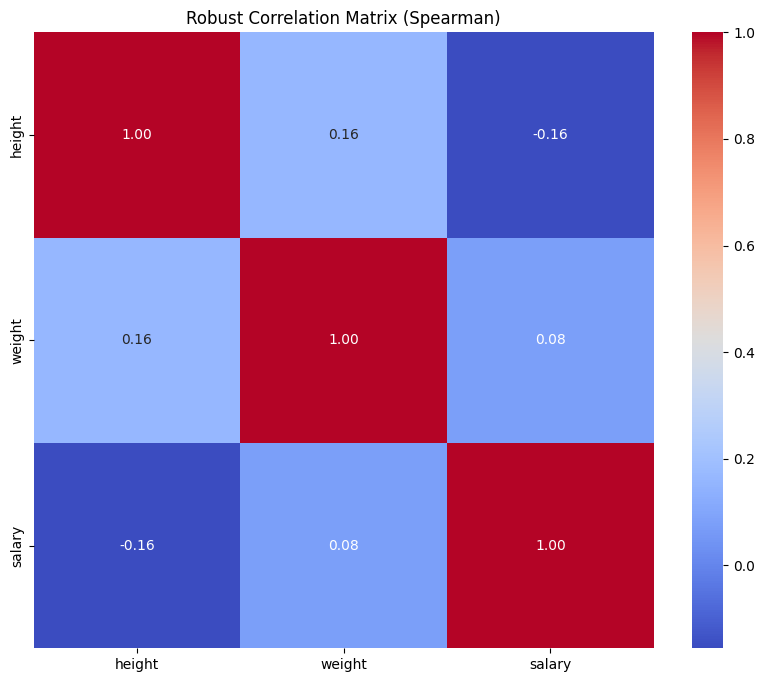

In [34]:
# Simple robust correlation calculation using Spearman instead of Pearson
robust_corr = df.corr(method='spearman')

plt.figure(figsize=(10, 8))
sns.heatmap(robust_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Robust Correlation Matrix (Spearman)')
plt.show()


In [35]:
# Apply different scaling methods before and after outlier treatment
from sklearn.preprocessing import StandardScaler, RobustScaler, MinMaxScaler

In [36]:
# Original data
scaler_standard = StandardScaler()
df_scaled_standard = pd.DataFrame(
    scaler_standard.fit_transform(df),
    columns=df.columns
)


In [37]:
# Using robust scaler which is less influenced by outliers
scaler_robust = RobustScaler()
df_scaled_robust = pd.DataFrame(
    scaler_robust.fit_transform(df),
    columns=df.columns
)

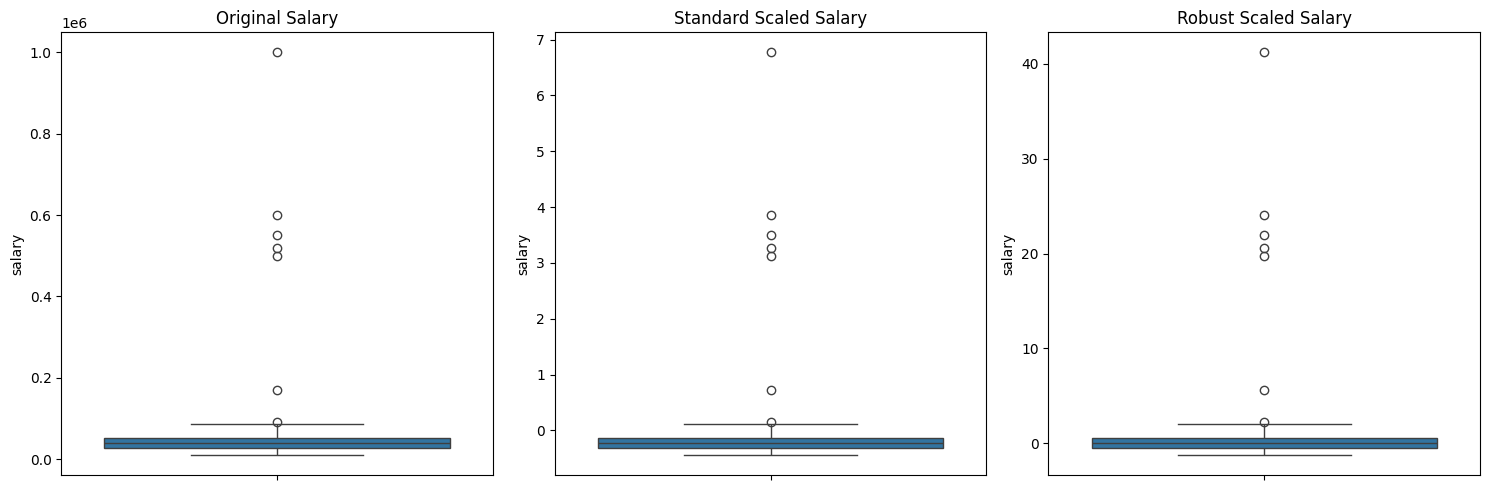

In [38]:
# Compare the scaled distributions
plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
sns.boxplot(y=df['salary'])
plt.title('Original Salary')

plt.subplot(1, 3, 2)
sns.boxplot(y=df_scaled_standard['salary'])
plt.title('Standard Scaled Salary')

plt.subplot(1, 3, 3)
sns.boxplot(y=df_scaled_robust['salary'])
plt.title('Robust Scaled Salary')

plt.tight_layout()
plt.show()


In [39]:
# Demonstrate impact of outliers on linear regression
from sklearn.linear_model import LinearRegression
import matplotlib.pyplot as plt

In [40]:
# Create dataset with outlier
x = np.array(range(20)).reshape(-1, 1)
y = 2*x.ravel() + 5 + np.random.normal(0, 1, 20)
y[19] = 80  # add outlier

plt.figure(figsize=(12, 6))


<Figure size 1200x600 with 0 Axes>

<Figure size 1200x600 with 0 Axes>

Text(0.5, 1.0, 'With Outlier: y = 2.57x + 1.40')

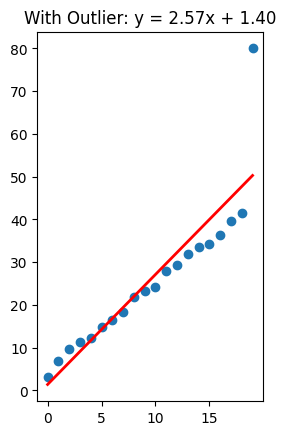

In [43]:
# Plot with outlier
plt.subplot(1, 2, 1)
plt.scatter(x, y)
model = LinearRegression().fit(x, y)
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'With Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')


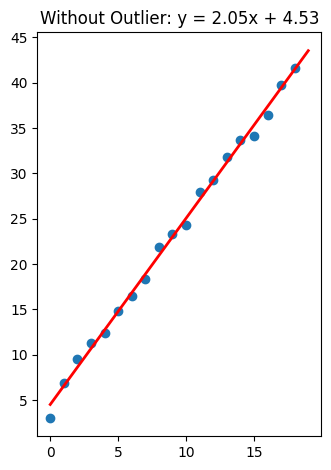

In [44]:
# Plot without outlier
plt.subplot(1, 2, 2)
plt.scatter(x[:-1], y[:-1])
model = LinearRegression().fit(x[:-1], y[:-1])
plt.plot(x, model.predict(x), color='red', linewidth=2)
plt.title(f'Without Outlier: y = {model.coef_[0]:.2f}x + {model.intercept_:.2f}')

plt.tight_layout()
plt.show()

# Interactive Coding Exercise: Advanced Outlier Detection & Analysis


In [ ]:
# ----------------------------------------------------------------
# In this exercise, you'll work with a real-world dataset to:
# 1. Apply outlier detection techniques
# 2. Compare methods and their impact
# 3. Implement a custom outlier detection workflow

In [1]:
# Import necessary libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.ensemble import IsolationForest
from sklearn.neighbors import LocalOutlierFactor
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# Load the California housing dataset instead of Boston
from sklearn.datasets import fetch_california_housing

# Load the dataset
housing = fetch_california_housing()
X = pd.DataFrame(housing.data, columns=housing.feature_names)
y = housing.target

# Create a DataFrame with all features plus the target
df = X.copy()
df['MedHouseVal'] = y  # The target is median house value

# Display basic information about the dataset
print("Dataset shape:", df.shape)
print("\nFeature names:", list(X.columns))
print("\nFirst 5 rows:")
df.head()

Dataset shape: (20640, 9)

Feature names: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude']

First 5 rows:


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


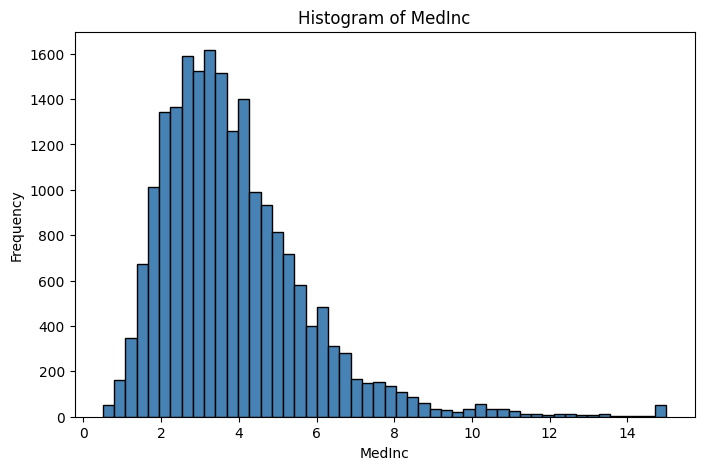

In [50]:
# EXERCISE 1: Exploratory Data Analysis for Outlier Detection
# -----------------------------------------------------------
# Select at least 3 features to inspect for outliers
plt.figure(figsize=(8, 5))
plt.hist(df['MedInc'], bins=50, color='steelblue', edgecolor='black')
plt.title('Histogram of MedInc')
plt.xlabel('MedInc')
plt.ylabel('Frequency')
plt.show()

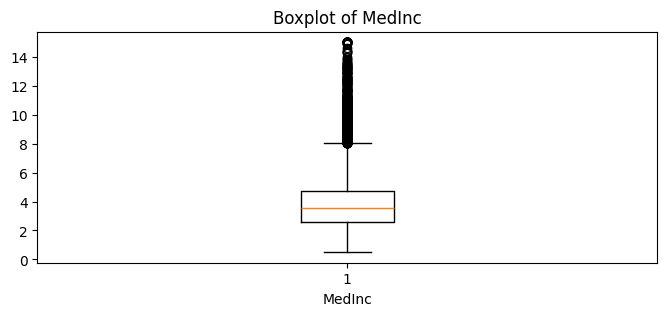

In [52]:
plt.figure(figsize=(8, 3))
plt.boxplot(df['MedInc'], vert=True)
plt.title('Boxplot of MedInc')
plt.xlabel('MedInc')
plt.show()

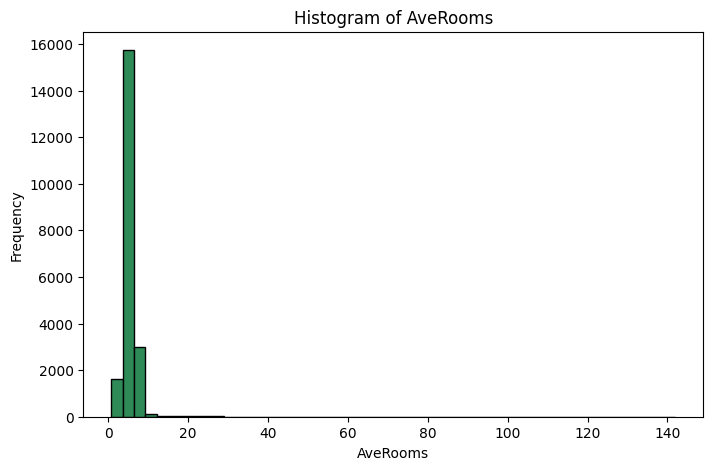

In [53]:
plt.figure(figsize=(8, 5))
plt.hist(df['AveRooms'], bins=50, color='seagreen', edgecolor='black')
plt.title('Histogram of AveRooms')
plt.xlabel('AveRooms')
plt.ylabel('Frequency')
plt.show()

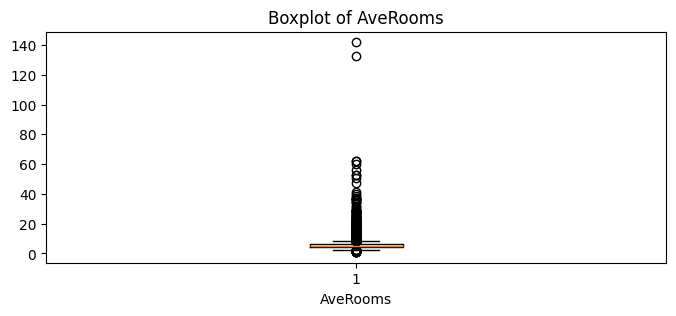

In [56]:
plt.figure(figsize=(8, 3))
plt.boxplot(df['AveRooms'], vert=True)
plt.title('Boxplot of AveRooms')
plt.xlabel('AveRooms')
plt.show()

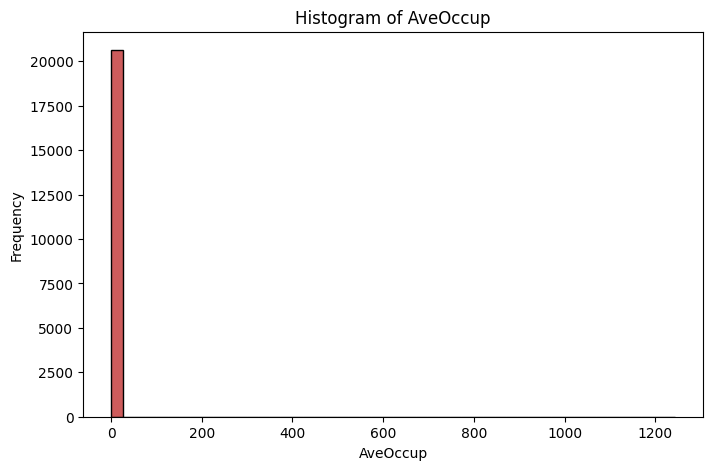

In [2]:
plt.figure(figsize=(8, 5))
plt.hist(df['AveOccup'], bins=50, color='indianred', edgecolor='black')
plt.title('Histogram of AveOccup')
plt.xlabel('AveOccup')
plt.ylabel('Frequency')
plt.show()

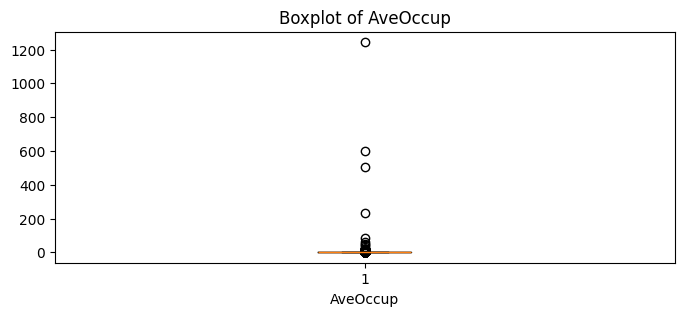

In [58]:
plt.figure(figsize=(8, 3))
plt.boxplot(df['AveOccup'], vert=True)
plt.title('Boxplot of AveOccup')
plt.xlabel('AveOccup')
plt.show()

In [59]:
# MedInc
q1_mi = df['MedInc'].quantile(0.25)
q3_mi = df['MedInc'].quantile(0.75)
iqr_mi = q3_mi - q1_mi
lower_mi = q1_mi - 1.5 * iqr_mi
upper_mi = q3_mi + 1.5 * iqr_mi
outliers_mi = ((df['MedInc'] < lower_mi) | (df['MedInc'] > upper_mi)).sum()
print(f"MedInc: {outliers_mi} potential outliers, bounds = [{lower_mi:.2f}, {upper_mi:.2f}]")

# AveRooms
q1_ar = df['AveRooms'].quantile(0.25)
q3_ar = df['AveRooms'].quantile(0.75)
iqr_ar = q3_ar - q1_ar
lower_ar = q1_ar - 1.5 * iqr_ar
upper_ar = q3_ar + 1.5 * iqr_ar
outliers_ar = ((df['AveRooms'] < lower_ar) | (df['AveRooms'] > upper_ar)).sum()
print(f"AveRooms: {outliers_ar} potential outliers, bounds = [{lower_ar:.2f}, {upper_ar:.2f}]")

# AveOccup
q1_ao = df['AveOccup'].quantile(0.25)
q3_ao = df['AveOccup'].quantile(0.75)
iqr_ao = q3_ao - q1_ao
lower_ao = q1_ao - 1.5 * iqr_ao
upper_ao = q3_ao + 1.5 * iqr_ao
outliers_ao = ((df['AveOccup'] < lower_ao) | (df['AveOccup'] > upper_ao)).sum()
print(f"AveOccup: {outliers_ao} potential outliers, bounds = [{lower_ao:.2f}, {upper_ao:.2f}]")

MedInc: 681 potential outliers, bounds = [-0.71, 8.01]
AveRooms: 511 potential outliers, bounds = [2.02, 8.47]
AveOccup: 711 potential outliers, bounds = [1.15, 4.56]


In [ ]:
# EXERCISE 2: Implement Multiple Outlier Detection Methods
# -------------------------------------------------------
# TODO: Implement both Z-score and IQR outlier detection for the LSTAT feature
# LSTAT: % lower status of the population

# Your implementation here

In [40]:
# Z-score outlier detection for MedHouseVal
mean_val = df['MedHouseVal'].mean()
std_val = df['MedHouseVal'].std()

df['MedHouseVal_zscore'] = (df['MedHouseVal'] - mean_val) / std_val

z_threshold = 3
z_outliers = df[np.abs(df['MedHouseVal_zscore']) > z_threshold]

print(f"Mean of MedHouseVal: {mean_val:.4f}")
print(f"Std of MedHouseVal: {std_val:.4f}")
print(f"Number of outliers (Z-score method, threshold={z_threshold}): {len(z_outliers)}")
print(f"Percentage of data: {(len(z_outliers) / len(df)) * 100:.2f}%")

Mean of MedHouseVal: 2.0686
Std of MedHouseVal: 1.1540
Number of outliers (Z-score method, threshold=3): 0
Percentage of data: 0.00%


In [41]:
# IQR outlier detection for MedHouseVal
q1_val = df['MedHouseVal'].quantile(0.25)
q3_val = df['MedHouseVal'].quantile(0.75)
iqr_val = q3_val - q1_val

lower_bound_val = q1_val - 1.5 * iqr_val
upper_bound_val = q3_val + 1.5 * iqr_val

iqr_outliers = df[(df['MedHouseVal'] < lower_bound_val) | (df['MedHouseVal'] > upper_bound_val)]

print(f"Q1: {q1_val:.4f}, Q3: {q3_val:.4f}, IQR: {iqr_val:.4f}")
print(f"Lower bound: {lower_bound_val:.4f}, Upper bound: {upper_bound_val:.4f}")
print(f"Number of outliers (IQR method): {len(iqr_outliers)}")
print(f"Percentage of data: {(len(iqr_outliers) / len(df)) * 100:.2f}%")

Q1: 1.1960, Q3: 2.6472, IQR: 1.4512
Lower bound: -0.9809, Upper bound: 4.8241
Number of outliers (IQR method): 1071
Percentage of data: 5.19%


In [42]:
# Compare Z-score vs IQR outlier detection
print("Comparison of Outlier Detection Methods on MedHouseVal")
print("-" * 55)
print(f"Z-score method found: {len(z_outliers)} outliers")
print(f"IQR method found: {len(iqr_outliers)} outliers")

common_outliers = pd.merge(z_outliers, iqr_outliers, how='inner')
print(f"Outliers detected by BOTH methods: {len(common_outliers)}")

Comparison of Outlier Detection Methods on MedHouseVal
-------------------------------------------------------
Z-score method found: 0 outliers
IQR method found: 1071 outliers
Outliers detected by BOTH methods: 0


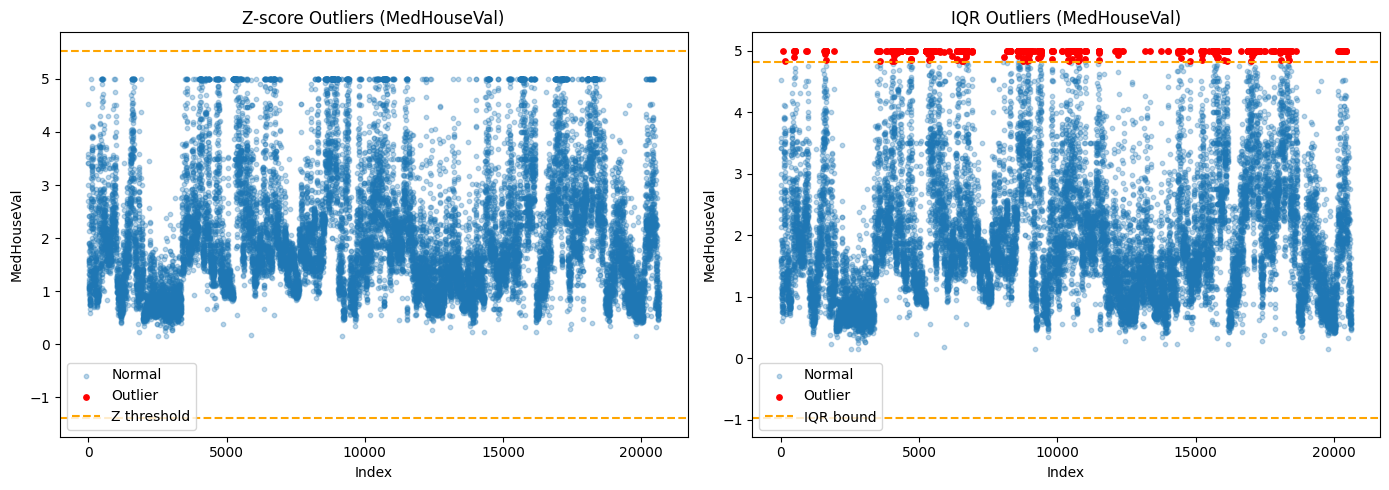

In [43]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Z-score visualization
axes[0].scatter(range(len(df)), df['MedHouseVal'], alpha=0.3, s=10, label='Normal')
axes[0].scatter(z_outliers.index, z_outliers['MedHouseVal'], color='red', s=15, label='Outlier')
axes[0].axhline(mean_val + z_threshold * std_val, color='orange', linestyle='--', label='Z threshold')
axes[0].axhline(mean_val - z_threshold * std_val, color='orange', linestyle='--')
axes[0].set_title('Z-score Outliers (MedHouseVal)')
axes[0].set_xlabel('Index')
axes[0].set_ylabel('MedHouseVal')
axes[0].legend()

# IQR visualization
axes[1].scatter(range(len(df)), df['MedHouseVal'], alpha=0.3, s=10, label='Normal')
axes[1].scatter(iqr_outliers.index, iqr_outliers['MedHouseVal'], color='red', s=15, label='Outlier')
axes[1].axhline(upper_bound_val, color='orange', linestyle='--', label='IQR bound')
axes[1].axhline(lower_bound_val, color='orange', linestyle='--')
axes[1].set_title('IQR Outliers (MedHouseVal)')
axes[1].set_xlabel('Index')
axes[1].set_ylabel('MedHouseVal')
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# EXERCISE 3: Advanced Outlier Detection - Isolation Forest
# --------------------------------------------------------
# TODO: Implement the Isolation Forest algorithm to detect outliers in the dataset
# Use contamination=0.05 (assuming 5% of data points are outliers)
# Return a binary mask where -1 represents outliers

# Your implementation here

In [7]:
# Use all features (excluding target) for outlier detection
X_features = df.drop(columns=['MedHouseVal'])

# Initialize and fit Isolation Forest
iso_forest = IsolationForest(contamination=0.05, random_state=42)
iso_forest.fit(X_features)

,n_estimators,100
,max_samples,'auto'
,contamination,0.05
,max_features,1.0
,bootstrap,False
,n_jobs,None
,random_state,42
,verbose,0
,warm_start,False


In [8]:
# Predict returns -1 for outliers and 1 for inliers
outlier_mask = iso_forest.predict(X_features)

df['IsoForest_Outlier'] = outlier_mask

n_outliers = (df['IsoForest_Outlier'] == -1).sum()
n_inliers = (df['IsoForest_Outlier'] == 1).sum()

print(f"Number of outliers detected: {n_outliers}")
print(f"Number of inliers: {n_inliers}")
print(f"Percentage of outliers: {(n_outliers / len(df)) * 100:.2f}%")

Number of outliers detected: 1032
Number of inliers: 19608
Percentage of outliers: 5.00%


In [9]:
# Lower scores indicate more abnormal points
df['IsoForest_Score'] = iso_forest.decision_function(X_features)

df[['IsoForest_Outlier', 'IsoForest_Score']].sort_values('IsoForest_Score').head(10)

,IsoForest_Outlier,IsoForest_Score
2511,-1,-0.201042
11849,-1,-0.197681
11862,-1,-0.196486
3258,-1,-0.196465
19736,-1,-0.191645
1102,-1,-0.187257
13034,-1,-0.182918
3350,-1,-0.180265
1926,-1,-0.179535
19006,-1,-0.178652


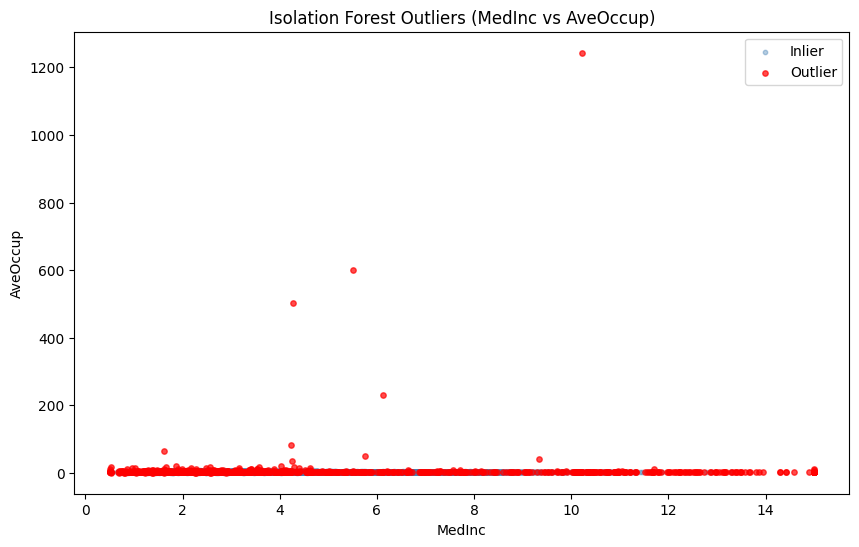

In [10]:
plt.figure(figsize=(10, 6))
plt.scatter(df.loc[df['IsoForest_Outlier'] == 1, 'MedInc'],
            df.loc[df['IsoForest_Outlier'] == 1, 'AveOccup'],
            c='steelblue', s=10, alpha=0.4, label='Inlier')
plt.scatter(df.loc[df['IsoForest_Outlier'] == -1, 'MedInc'],
            df.loc[df['IsoForest_Outlier'] == -1, 'AveOccup'],
            c='red', s=15, alpha=0.7, label='Outlier')
plt.xlabel('MedInc')
plt.ylabel('AveOccup')
plt.title('Isolation Forest Outliers (MedInc vs AveOccup)')
plt.legend()
plt.show()

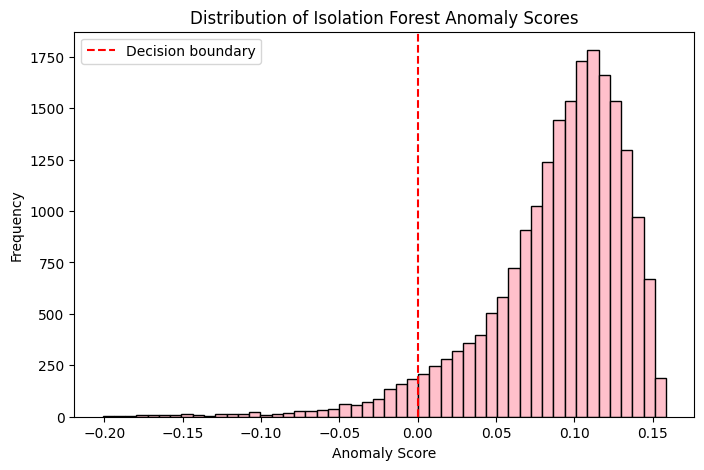

In [13]:
plt.figure(figsize=(8, 5))
plt.hist(df['IsoForest_Score'], bins=50, color='pink', edgecolor='black')
plt.axvline(0, color='red', linestyle='--', label='Decision boundary')
plt.title('Distribution of Isolation Forest Anomaly Scores')
plt.xlabel('Anomaly Score')
plt.ylabel('Frequency')
plt.legend()
plt.show()

In [ ]:
# EXERCISE 4: Compare the Impact of Outliers on Linear Regression
# --------------------------------------------------------------
# TODO:
# 1. Create a simple linear regression model using 'LSTAT' to predict 'PRICE'
# 2. Create 3 versions:
#    a. With all data
#    b. After removing Z-score outliers
#    c. After removing Isolation Forest outliers
# 3. Compare the model performance metrics (r2_score) and coefficients

# Your implementation here


In [14]:
X_all = df[['MedInc']]
y_all = df['MedHouseVal']

X_train_all, X_test_all, y_train_all, y_test_all = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

model_all = LinearRegression()
model_all.fit(X_train_all, y_train_all)

y_pred_all = model_all.predict(X_test_all)

r2_all = r2_score(y_test_all, y_pred_all)
mse_all = mean_squared_error(y_test_all, y_pred_all)

print("Model (a) - All Data")
print(f"Coefficient: {model_all.coef_[0]:.4f}")
print(f"Intercept: {model_all.intercept_:.4f}")
print(f"R2 Score: {r2_all:.4f}")
print(f"MSE: {mse_all:.4f}")

Model (a) - All Data
Coefficient: 0.4193
Intercept: 0.4446
R2 Score: 0.4589
MSE: 0.7091


In [15]:
mean_medinc = df['MedInc'].mean()
std_medinc = df['MedInc'].std()

df['MedInc_zscore'] = (df['MedInc'] - mean_medinc) / std_medinc

z_threshold = 3
df_no_zscore_outliers = df[np.abs(df['MedInc_zscore']) <= z_threshold]

print(f"Original data size: {len(df)}")
print(f"Data size after removing Z-score outliers: {len(df_no_zscore_outliers)}")
print(f"Removed: {len(df) - len(df_no_zscore_outliers)} rows")

Original data size: 20640
Data size after removing Z-score outliers: 20295
Removed: 345 rows


In [16]:
X_zscore = df_no_zscore_outliers[['MedInc']]
y_zscore = df_no_zscore_outliers['MedHouseVal']

X_train_z, X_test_z, y_train_z, y_test_z = train_test_split(
    X_zscore, y_zscore, test_size=0.2, random_state=42
)

model_zscore = LinearRegression()
model_zscore.fit(X_train_z, y_train_z)

y_pred_z = model_zscore.predict(X_test_z)

r2_zscore = r2_score(y_test_z, y_pred_z)
mse_zscore = mean_squared_error(y_test_z, y_pred_z)

print("Model (b) - After Removing Z-score Outliers")
print(f"Coefficient: {model_zscore.coef_[0]:.4f}")
print(f"Intercept: {model_zscore.intercept_:.4f}")
print(f"R2 Score: {r2_zscore:.4f}")
print(f"MSE: {mse_zscore:.4f}")

Model (b) - After Removing Z-score Outliers
Coefficient: 0.4505
Intercept: 0.3340
R2 Score: 0.4313
MSE: 0.7069


In [19]:
df_no_iso_outliers = df[df['IsoForest_Outlier'] == 1]

X_iso = df_no_iso_outliers[['MedInc']]
y_iso = df_no_iso_outliers['MedHouseVal']

X_train_iso, X_test_iso, y_train_iso, y_test_iso = train_test_split(
    X_iso, y_iso, test_size=0.2, random_state=42
)

model_iso = LinearRegression()
model_iso.fit(X_train_iso, y_train_iso)

y_pred_iso = model_iso.predict(X_test_iso)

r2_iso = r2_score(y_test_iso, y_pred_iso)
mse_iso = mean_squared_error(y_test_iso, y_pred_iso)

print("Model (c) - After Removing Isolation Forest Outliers")
print(f"Coefficient: {model_iso.coef_[0]:.4f}")
print(f"Intercept: {model_iso.intercept_:.4f}")
print(f"R2 Score: {r2_iso:.4f}")
print(f"MSE: {mse_iso:.4f}")

Model (c) - After Removing Isolation Forest Outliers
Coefficient: 0.4491
Intercept: 0.3456
R2 Score: 0.4870
MSE: 0.6457


In [20]:
comparison_df = pd.DataFrame({
    'Model': ['All Data', 'Z-score Cleaned', 'Isolation Forest Cleaned'],
    'Coefficient': [model_all.coef_[0], model_zscore.coef_[0], model_iso.coef_[0]],
    'Intercept': [model_all.intercept_, model_zscore.intercept_, model_iso.intercept_],
    'R2 Score': [r2_all, r2_zscore, r2_iso],
    'MSE': [mse_all, mse_zscore, mse_iso]
})

comparison_df

,Model,Coefficient,Intercept,R2 Score,MSE
0,All Data,0.419338,0.444597,0.458859,0.709116
1,Z-score Cleaned,0.450546,0.334043,0.431255,0.706949
2,Isolation Forest Cleaned,0.449052,0.345584,0.487032,0.645740


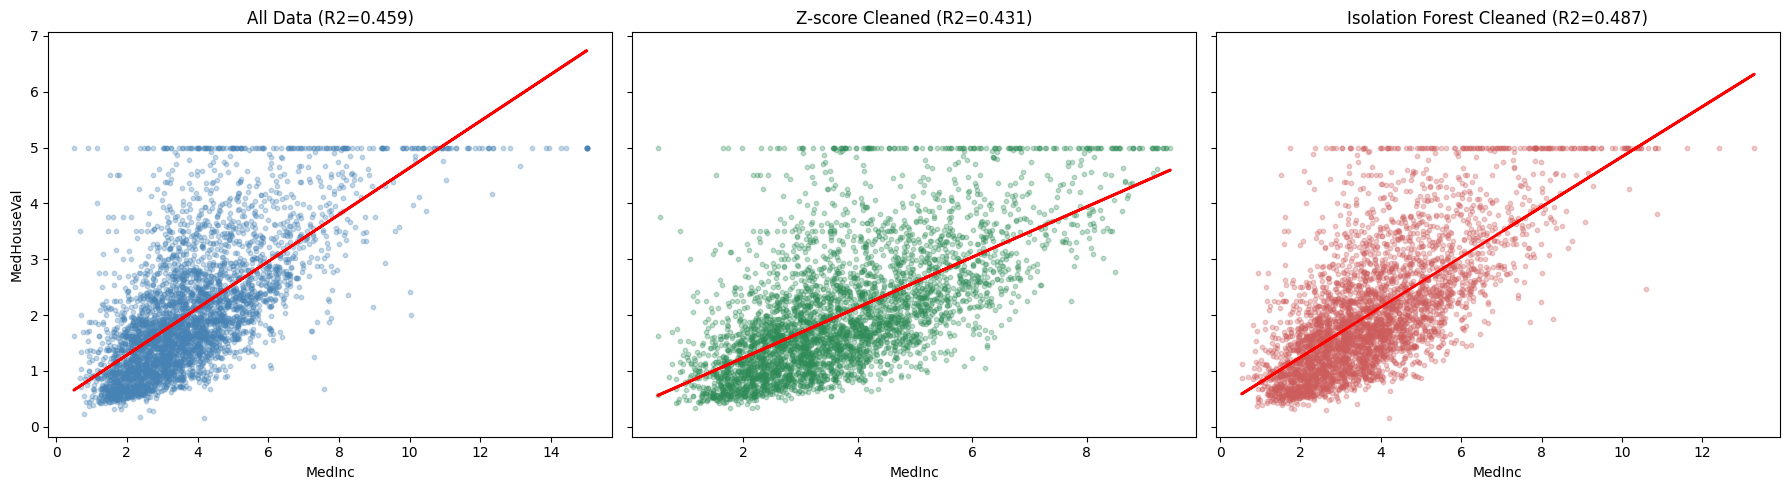

In [21]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)

axes[0].scatter(X_test_all, y_test_all, alpha=0.3, s=10, color='steelblue')
axes[0].plot(X_test_all, y_pred_all, color='red', linewidth=2)
axes[0].set_title(f'All Data (R2={r2_all:.3f})')
axes[0].set_xlabel('MedInc')
axes[0].set_ylabel('MedHouseVal')

axes[1].scatter(X_test_z, y_test_z, alpha=0.3, s=10, color='seagreen')
axes[1].plot(X_test_z, y_pred_z, color='red', linewidth=2)
axes[1].set_title(f'Z-score Cleaned (R2={r2_zscore:.3f})')
axes[1].set_xlabel('MedInc')

axes[2].scatter(X_test_iso, y_test_iso, alpha=0.3, s=10, color='indianred')
axes[2].plot(X_test_iso, y_pred_iso, color='red', linewidth=2)
axes[2].set_title(f'Isolation Forest Cleaned (R2={r2_iso:.3f})')
axes[2].set_xlabel('MedInc')

plt.tight_layout()
plt.show()

In [ ]:
df_no_iso_outliers = df[df['IsoForest_Outlier'] == 1]

X_iso = df_no_iso_outliers[['MedInc']]
y_iso = df_no_iso_outliers['MedHouseVal']

X_train_iso, X_test_iso, y_train_iso, y_test_iso = train_test_split(
    X_iso, y_iso, test_size=0.2, random_state=42
)

model_iso = LinearRegression()
model_iso.fit(X_train_iso, y_train_iso)

y_pred_iso = model_iso.predict(X_test_iso)

r2_iso = r2_score(y_test_iso, y_pred_iso)
mse_iso = mean_squared_error(y_test_iso, y_pred_iso)

print("Model (c) - After Removing Isolation Forest Outliers")
print(f"Coefficient: {model_iso.coef_[0]:.4f}")
print(f"Intercept: {model_iso.intercept_:.4f}")
print(f"R2 Score: {r2_iso:.4f}")
print(f"MSE: {mse_iso:.4f}")

In [ ]:
# EXERCISE 5: Create Your Own Outlier Detection Workflow
# -----------------------------------------------------
# TODO: Create a custom outlier detection function that combines multiple methods
# It should:
# 1. Take a dataframe and column name as input
# 2. Apply at least 2 different outlier detection methods (of your choice)
# 3. Return the indices of consensus outliers (detected by both methods)
# 4. Include a visualization of the outliers

# Your implementation here

In [22]:
# EXERCISE 6: Robust Feature Engineering with Outliers
# ---------------------------------------------------
# TODO: Create a new feature that is more robust to outliers
# Suggestions:
# - Use log transformation
# - Use binning/discretization
# - Create a ratio or interaction feature
# Compare the distribution before and after your transformation

# Your implementation here
# Log transformation compresses large values, reducing the pull of outliers
df['AveOccup_log'] = np.log1p(df['AveOccup'])  # log1p handles zero values safely

print("Original AveOccup stats:")
print(df['AveOccup'].describe())
print("\nLog-transformed AveOccup stats:")
print(df['AveOccup_log'].describe())

Original AveOccup stats:
count    20640.000000
mean         3.070655
std         10.386050
min          0.692308
25%          2.429741
50%          2.818116
75%          3.282261
max       1243.333333
Name: AveOccup, dtype: float64

Log-transformed AveOccup stats:
count    20640.000000
mean         1.351645
std          0.207530
min          0.526093
25%          1.232485
50%          1.339757
75%          1.454481
max          7.126355
Name: AveOccup_log, dtype: float64


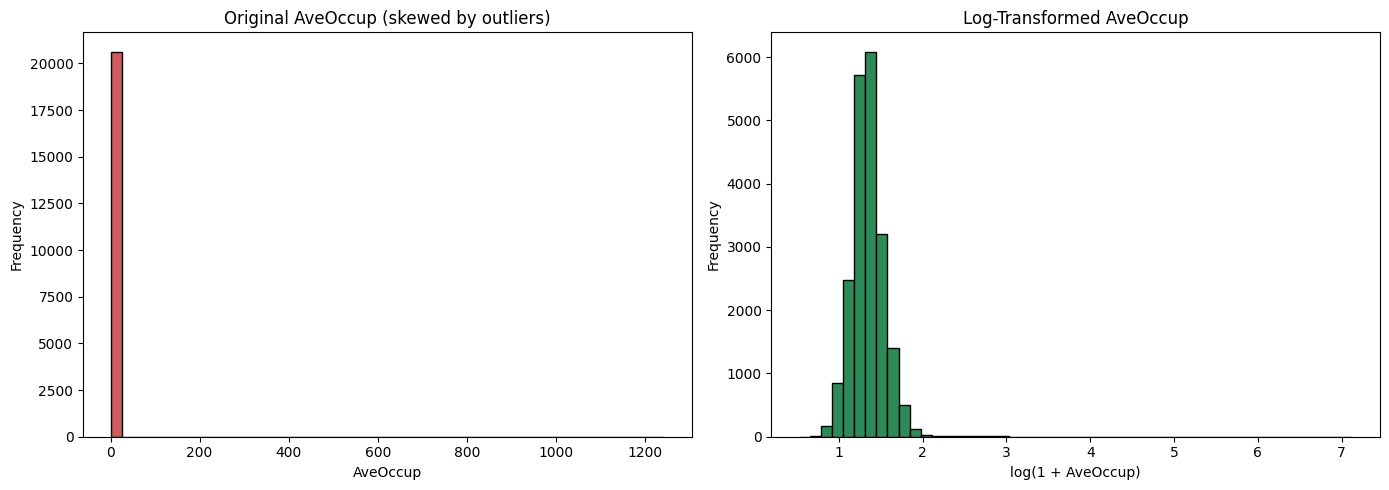

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['AveOccup'], bins=50, color='indianred', edgecolor='black')
axes[0].set_title('Original AveOccup (skewed by outliers)')
axes[0].set_xlabel('AveOccup')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['AveOccup_log'], bins=50, color='seagreen', edgecolor='black')
axes[1].set_title('Log-Transformed AveOccup')
axes[1].set_xlabel('log(1 + AveOccup)')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [24]:
# Binning converts continuous values into categories, capping the influence of extreme values
bin_edges = [0, 2, 3, 4, 6, df['AveOccup'].max() + 1]
bin_labels = ['Very Low', 'Low', 'Medium', 'High', 'Very High']

df['AveOccup_binned'] = pd.cut(df['AveOccup'], bins=bin_edges, labels=bin_labels)

print(df['AveOccup_binned'].value_counts())

AveOccup_binned
Low          11001
Medium        6247
Very Low      1651
High          1627
Very High      114
Name: count, dtype: int64


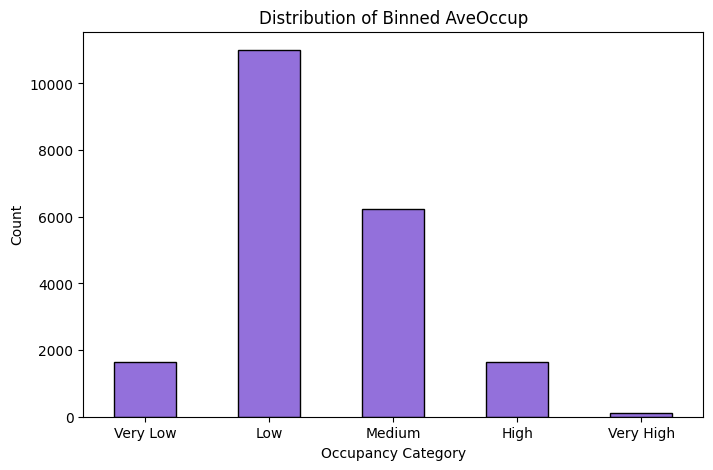

In [25]:
plt.figure(figsize=(8, 5))
df['AveOccup_binned'].value_counts().reindex(bin_labels).plot(kind='bar', color='mediumpurple', edgecolor='black')
plt.title('Distribution of Binned AveOccup')
plt.xlabel('Occupancy Category')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.show()

In [26]:
# Ratio feature: average rooms available per occupant
# More robust than raw AveRooms or AveOccup alone, since it normalizes household size against space
df['Rooms_per_Person'] = df['AveRooms'] / df['AveOccup']

print("Rooms_per_Person stats:")
print(df['Rooms_per_Person'].describe())

Rooms_per_Person stats:
count    20640.000000
mean         1.976970
std          1.146020
min          0.002547
25%          1.522382
50%          1.937936
75%          2.296090
max         55.222222
Name: Rooms_per_Person, dtype: float64


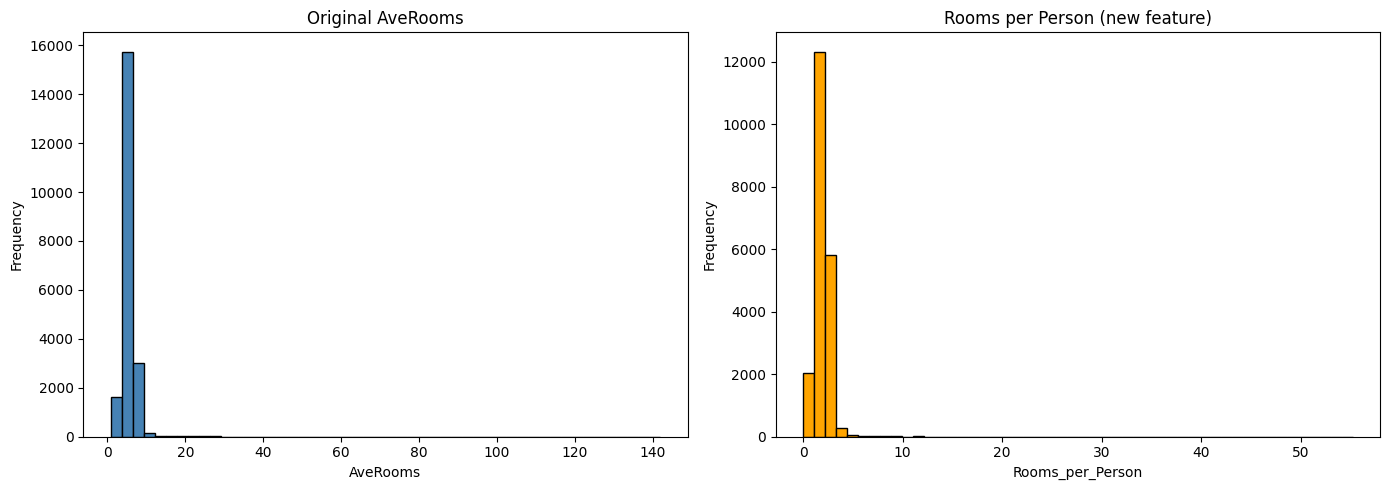

In [29]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].hist(df['AveRooms'], bins=50, color='steelblue', edgecolor='black')
axes[0].set_title('Original AveRooms')
axes[0].set_xlabel('AveRooms')
axes[0].set_ylabel('Frequency')

axes[1].hist(df['Rooms_per_Person'], bins=50, color='orange', edgecolor='black')
axes[1].set_title('Rooms per Person (new feature)')
axes[1].set_xlabel('Rooms_per_Person')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

In [30]:
summary = pd.DataFrame({
    'Feature': ['AveOccup (original)', 'AveOccup_log', 'Rooms_per_Person'],
    'Skewness': [df['AveOccup'].skew(), df['AveOccup_log'].skew(), df['Rooms_per_Person'].skew()],
    'Std Dev': [df['AveOccup'].std(), df['AveOccup_log'].std(), df['Rooms_per_Person'].std()],
    'Max': [df['AveOccup'].max(), df['AveOccup_log'].max(), df['Rooms_per_Person'].max()]
})

summary

,Feature,Skewness,Std Dev,Max
0,AveOccup (original),97.639561,10.38605,1243.333333
1,AveOccup_log,3.879679,0.20753,7.126355
2,Rooms_per_Person,17.775133,1.14602,55.222222


In [31]:
# EXERCISE 7: BONUS CHALLENGE - Multivariate Outlier Detection
# ------------------------------------------------------------
# TODO: Implement a multivariate outlier detection method using Mahalanobis distance
# Calculate the distance for each point and identify outliers using a chi-squared threshold
# Visualize the results using a scatter plot matrix highlighting the outliers

# Your implementation here
# Select a subset of numeric features for multivariate outlier detection
mv_features = ['MedInc', 'AveRooms', 'AveOccup', 'HouseAge']
X_mv = df[mv_features].values

mean_vec = np.mean(X_mv, axis=0)
cov_matrix = np.cov(X_mv, rowvar=False)
inv_cov_matrix = np.linalg.inv(cov_matrix)

print("Mean vector:", mean_vec)
print("\nCovariance matrix:\n", cov_matrix)

Mean vector: [ 3.870671    5.42899974  3.07065516 28.63948643]

Covariance matrix:
 [[ 3.60932256e+00  1.53656801e+00  3.70288896e-01 -2.84614028e+00]
 [ 1.53656801e+00  6.12153272e+00 -1.24688866e-01 -4.77288245e+00]
 [ 3.70288896e-01 -1.24688866e-01  1.07870026e+02  1.72429796e+00]
 [-2.84614028e+00 -4.77288245e+00  1.72429796e+00  1.58396260e+02]]


In [32]:
# Mahalanobis distance: sqrt((x - mean)^T * inv(cov) * (x - mean))
diff = X_mv - mean_vec
left_term = diff @ inv_cov_matrix
mahal_dist_sq = np.sum(left_term * diff, axis=1)  # squared distance for each row
mahal_dist = np.sqrt(mahal_dist_sq)

df['Mahalanobis_Dist'] = mahal_dist

df[['MedInc', 'AveRooms', 'AveOccup', 'HouseAge', 'Mahalanobis_Dist']].head()

,MedInc,AveRooms,AveOccup,HouseAge,Mahalanobis_Dist
0,8.3252,6.984127,2.555556,41.0,2.669103
1,8.3014,6.238137,2.109842,21.0,2.412993
2,7.2574,8.288136,2.802260,52.0,2.876649
3,5.6431,5.817352,2.547945,52.0,2.193790
4,3.8462,6.281853,2.181467,52.0,1.965335


In [33]:
# Squared Mahalanobis distance follows a chi-squared distribution
# with degrees of freedom = number of features
dof = len(mv_features)
chi2_threshold = stats.chi2.ppf(0.975, dof)  # 97.5th percentile -> ~5% flagged as outliers

df['Mahalanobis_Outlier'] = mahal_dist_sq > chi2_threshold

n_outliers_mv = df['Mahalanobis_Outlier'].sum()

print(f"Degrees of freedom: {dof}")
print(f"Chi-squared threshold (97.5%): {chi2_threshold:.4f}")
print(f"Number of multivariate outliers detected: {n_outliers_mv}")
print(f"Percentage of data: {(n_outliers_mv / len(df)) * 100:.2f}%")

Degrees of freedom: 4
Chi-squared threshold (97.5%): 11.1433
Number of multivariate outliers detected: 459
Percentage of data: 2.22%


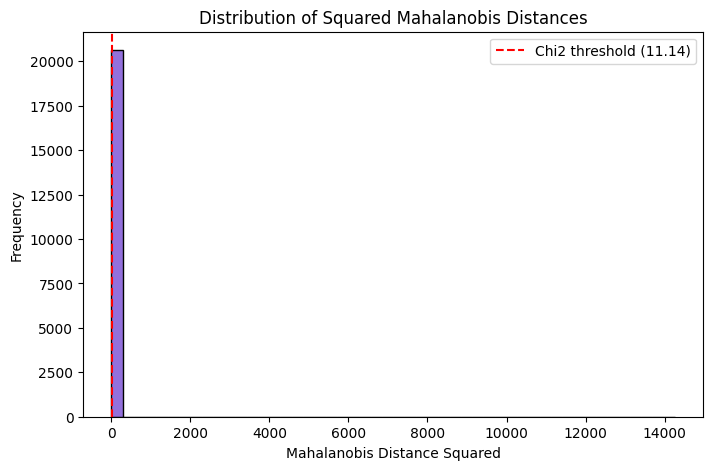

In [34]:
plt.figure(figsize=(8, 5))
plt.hist(mahal_dist_sq, bins=50, color='mediumpurple', edgecolor='black')
plt.axvline(chi2_threshold, color='red', linestyle='--', label=f'Chi2 threshold ({chi2_threshold:.2f})')
plt.title('Distribution of Squared Mahalanobis Distances')
plt.xlabel('Mahalanobis Distance Squared')
plt.ylabel('Frequency')
plt.legend()
plt.show()

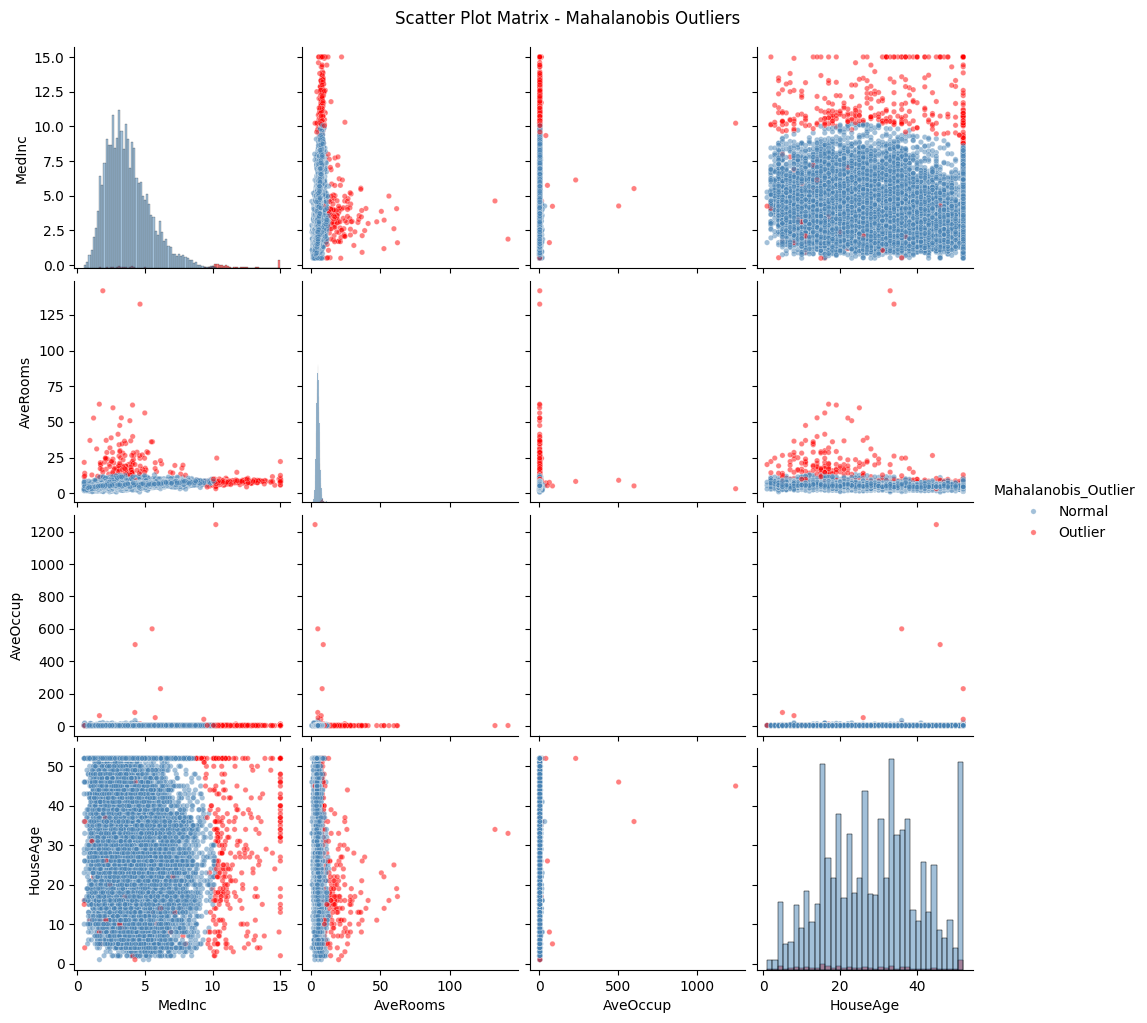

In [39]:
pairplot_df = df[mv_features + ['Mahalanobis_Outlier']].copy()
pairplot_df['Mahalanobis_Outlier'] = pairplot_df['Mahalanobis_Outlier'].map({True: 'Outlier', False: 'Normal'})

sns.pairplot(
    pairplot_df,
    hue='Mahalanobis_Outlier',
    palette={'Normal': 'steelblue', 'Outlier': 'red'},
    diag_kind='hist',
    plot_kws={'alpha': 0.5, 's': 15}
)
plt.suptitle('Scatter Plot Matrix - Mahalanobis Outliers', y=1.02)
plt.show()

In [36]:
agreement = (df['Mahalanobis_Outlier'] == (df['IsoForest_Outlier'] == -1)).sum()
overlap_outliers = ((df['Mahalanobis_Outlier']) & (df['IsoForest_Outlier'] == -1)).sum()

print(f"Mahalanobis outliers: {df['Mahalanobis_Outlier'].sum()}")
print(f"Isolation Forest outliers: {(df['IsoForest_Outlier'] == -1).sum()}")
print(f"Points flagged by BOTH methods: {overlap_outliers}")
print(f"Overall agreement rate: {(agreement / len(df)) * 100:.2f}%")

Mahalanobis outliers: 459
Isolation Forest outliers: 1032
Points flagged by BOTH methods: 342
Overall agreement rate: 96.09%
